<a href="https://colab.research.google.com/github/segmentSK9/Projet-GNN-/blob/main/PROJET_GNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification des nœuds avec un GCN

## Objectif

L'objectif de ce projet est d'utiliser un Graph Convolutional Network (GCN) pour effectuer une tâche de classification sur un graphe représentant un réseau d'aéroports.

Chaque nœud du graphe représente un aéroport et les arêtes représentent les connexions entre les aéroports.

Dans un premier temps, nous allons charger et explorer le graphe afin d'identifier les informations disponibles pour chaque nœud.


In [ ]:
import networkx as nx #charger et manipuler le graphe
G = nx.read_graphml("airportsAndCoordAndPop.graphml")

print(G)
print("Nombre de nœuds :", G.number_of_nodes())
print("Nombre d'arêtes :", G.number_of_edges())

Graph with 3363 nodes and 13547 edges
Nombre de nœuds : 3363
Nombre d'arêtes : 13547


## 2. Exploration des attributs des nœuds

Avant de construire les données d'entrée du GCN, nous devons identifier les informations associées aux aéroports.

Nous affichons donc un premier nœud ainsi que l'ensemble de ses attributs.

In [ ]:
node, attrs = next(iter(G.nodes(data=True)))

print("Premier nœud :", node)
print("Attributs :", attrs)
print("Attributs disponibles :")
print(list(attrs.keys()))

Premier nœud : 0
Attributs : {'lon': -145.50972222222222, 'lat': -17.35388888888889, 'population': 10000, 'country': 'FRENCH_POLYNESIA', 'city_name': 'Anaa'}
Attributs disponibles :
['lon', 'lat', 'population', 'country', 'city_name']


## 3. Vérification des données

Pour entraîner un GCN, les caractéristiques utilisées en entrée doivent être numériques et exploitables par PyTorch.

Nous allons utiliser comme caractéristiques des nœuds :

- `population` : population de la ville associée à l'aéroport ;
- `lat` : latitude de l'aéroport ;
- `lon` : longitude de l'aéroport.

La variable `country` sera utilisée comme cible de classification.

Avant de construire les tenseurs PyTorch, nous vérifions si certaines de ces informations sont manquantes dans le graphe.

In [ ]:
features = ["population", "lat", "lon", "country"]

for feature in features:
    missing = sum(
        feature not in data or data[feature] is None
        for _, data in G.nodes(data=True)
    )

    print(feature, ":", missing, "valeurs manquantes")

population : 0 valeurs manquantes
lat : 0 valeurs manquantes
lon : 0 valeurs manquantes
country : 0 valeurs manquantes


## Visualisation du graphe

Une première visualisation permet d'observer la structure générale du réseau d'aéroports.

Les coordonnées géographiques disponibles dans les données (`lon` et `lat`) sont utilisées pour positionner les nœuds. Chaque nœud représente un aéroport et chaque arête représente une connexion entre deux aéroports.

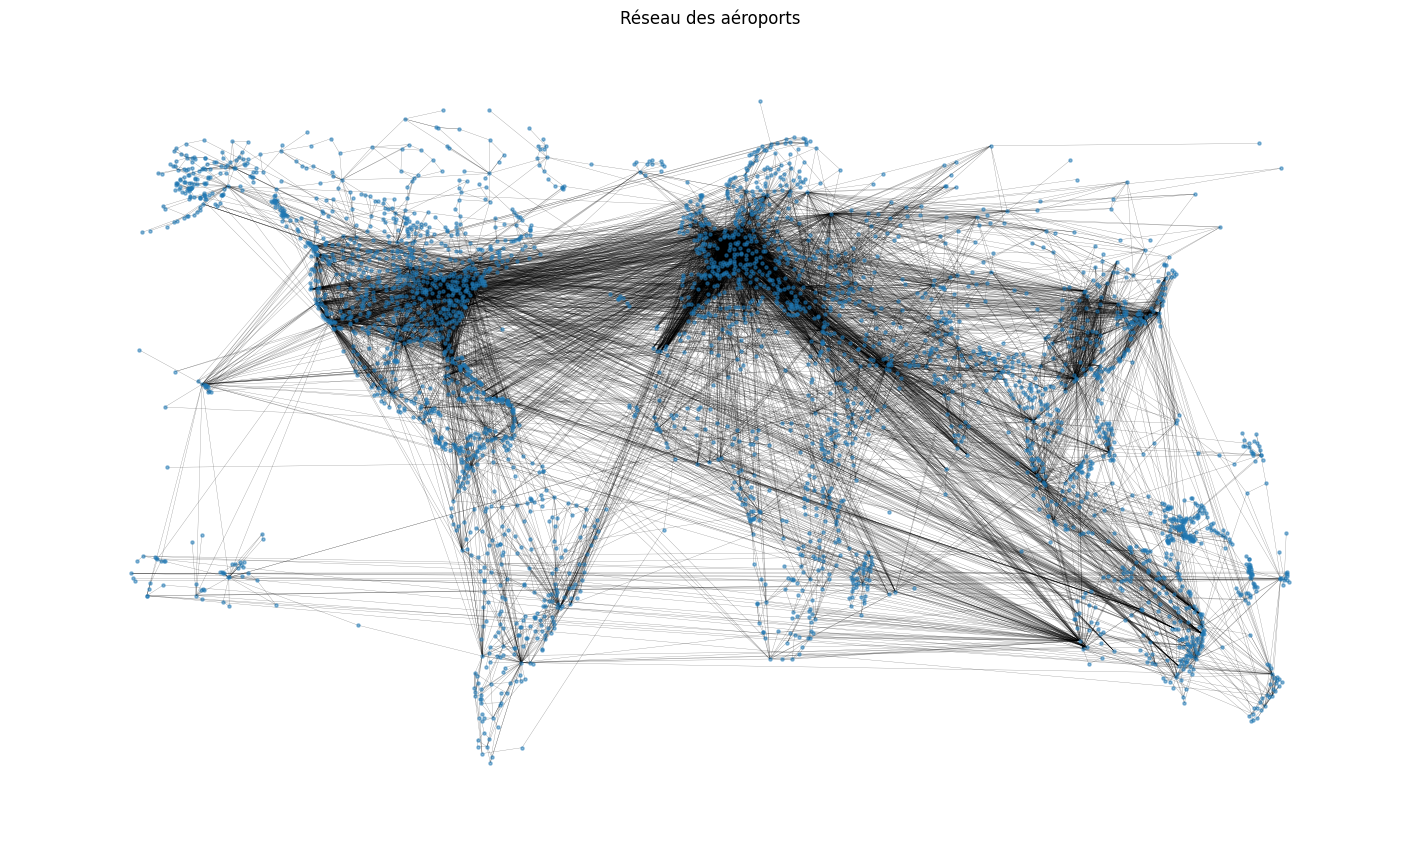

In [ ]:
import matplotlib.pyplot as plt

pos = {
    node: (data["lon"], data["lat"])
    for node, data in G.nodes(data=True)
}

plt.figure(figsize=(14, 8))

nx.draw(
    G,
    pos,
    node_size=5,
    width=0.2,
    alpha=0.5,
    with_labels=False
)

plt.title("Réseau des aéroports")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

## Analyse des connexions

Le degré d'un nœud correspond au nombre de connexions de cet aéroport avec les autres aéroports du réseau.

Quelques statistiques sur les degrés permettent d'avoir une première idée de la connectivité du graphe.

In [ ]:
degrees = [degree for node, degree in G.degree()]

print("Degré minimum :", min(degrees))
print("Degré maximum :", max(degrees))
print("Degré moyen :", sum(degrees) / len(degrees))

Degré minimum : 1
Degré maximum : 248
Degré moyen : 8.056497175141242


### Distribution des degrés

La distribution des degrés permet d'observer comment le nombre de connexions varie entre les différents aéroports.

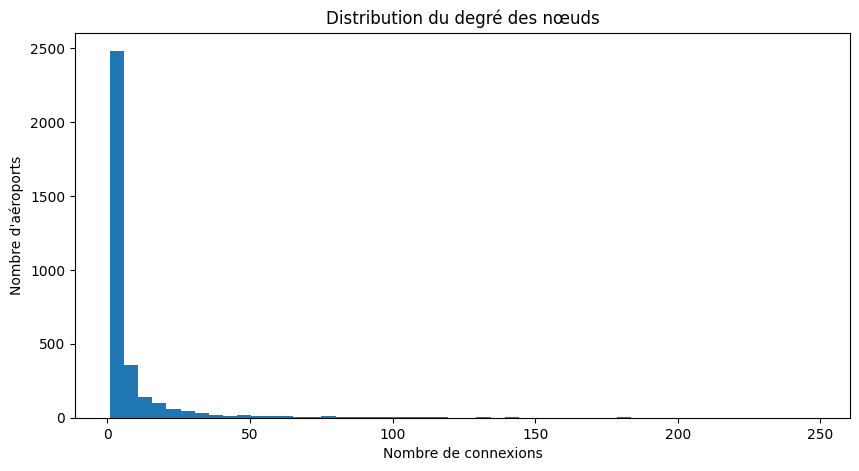

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(degrees, bins=50)

plt.xlabel("Nombre de connexions")
plt.ylabel("Nombre d'aéroports")
plt.title("Distribution du degré des nœuds")

plt.show()

## Préparation de la variable cible

La propriété `country` correspond à la classe à prédire pour chaque aéroport.

Les noms des pays sont représentés sous forme de texte dans le graphe. Pour pouvoir les utiliser avec PyTorch, ces valeurs doivent être transformées en classes numériques.

Un `LabelEncoder` est utilisé pour associer un entier différent à chaque pays.

In [ ]:
from sklearn.preprocessing import LabelEncoder

countries = [
    data["country"]
    for node, data in G.nodes(data=True)
]

encoder = LabelEncoder()

labels = encoder.fit_transform(countries)

print("Nombre de pays :", len(encoder.classes_))
print("Premiers pays :", countries[:5])
print("Premiers labels :", labels[:5])

Nombre de pays : 212
Premiers pays : ['FRENCH_POLYNESIA', 'FRENCH_POLYNESIA', 'FRENCH_POLYNESIA', 'FRENCH_POLYNESIA', 'FRENCH_POLYNESIA']
Premiers labels : [66 66 66 66 66]


### Vérification des classes

Quelques correspondances entre les noms des pays et les labels numériques sont affichées afin de vérifier le résultat de l'encodage.

In [ ]:
for i in range(10):
    print(encoder.classes_[i], "->", i)

AFGHANISTAN -> 0
ALBANIA -> 1
ALGERIA -> 2
AMERICAN_SAMOA -> 3
ANGOLA -> 4
ANGUILLA -> 5
ANTIGUA_AND_BARBUDA -> 6
ARGENTINA -> 7
ARMENIA -> 8
AUSTRALIA -> 9


## Construction des données d'entrée

Pour chaque aéroport, trois caractéristiques numériques sont utilisées : la population de la ville, la latitude et la longitude.

Ces valeurs constituent la matrice `x` utilisée en entrée du GCN.

Les pays encodés précédemment constituent le vecteur `y`, qui contient la classe à prédire pour chaque nœud.

In [ ]:
import torch

x = []

for node, data in G.nodes(data=True):
    x.append([
        data["population"],
        data["lat"],
        data["lon"]
    ])

x = torch.tensor(x, dtype=torch.float)
y = torch.tensor(labels, dtype=torch.long)

print("Shape de x :", x.shape)
print("Shape de y :", y.shape)
print("\nPremier x :", x[0])
print("Premier y :", y[0])

Shape de x : torch.Size([3363, 3])
Shape de y : torch.Size([3363])

Premier x : tensor([10000.0000,   -17.3539,  -145.5097])
Premier y : tensor(66)


### Vérification des données

La matrice `x` doit contenir une ligne par aéroport et une colonne par caractéristique.

Le vecteur `y` doit contenir exactement une classe pour chaque nœud du graphe.

In [ ]:
print("Nombre de nœuds :", G.number_of_nodes())
print("Nombre de lignes dans x :", x.shape[0])
print("Nombre de labels dans y :", y.shape[0])
print("Nombre de caractéristiques :", x.shape[1])
print("Nombre de classes :", len(encoder.classes_))

Nombre de nœuds : 3363
Nombre de lignes dans x : 3363
Nombre de labels dans y : 3363
Nombre de caractéristiques : 3
Nombre de classes : 212


## Normalisation des caractéristiques

Les trois caractéristiques utilisées n'ont pas la même échelle. La population peut atteindre des valeurs très élevées, alors que la latitude et la longitude restent dans des intervalles beaucoup plus petits.

Une standardisation est donc appliquée afin que chaque caractéristique ait une moyenne proche de 0 et un écart-type proche de 1.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_scaled = scaler.fit_transform(x.numpy())

x = torch.tensor(x_scaled, dtype=torch.float)

print("Moyenne :", x.mean(dim=0))
print("Écart-type :", x.std(dim=0))
print("\nPremier nœud après normalisation :", x[0])

Moyenne : tensor([7.9402e-09, 1.6448e-08, 1.2477e-08])
Écart-type : tensor([1.0001, 1.0001, 1.0001])

Premier nœud après normalisation : tensor([-0.2599, -1.3766, -1.5157])


## Conversion vers PyTorch Geometric

Le graphe doit maintenant être représenté sous la forme utilisée par PyTorch Geometric.

Les connexions entre les aéroports sont converties en `edge_index`. Les caractéristiques `x` et les classes `y` sont ensuite regroupées avec ces connexions dans un objet `Data`.

In [ ]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.7 MB/s eta 0:00:00


In [ ]:
from torch_geometric.utils import from_networkx

data = from_networkx(G)

data.x = x
data.y = y

print(data)

Data(edge_index=[2, 27094], lon=[3363], lat=[3363], population=[3363], country=[3363], city_name=[3363], num_nodes=3363, x=[3363, 3], y=[3363])


### Vérification de l'objet Data

Avant de construire le GCN, les dimensions des données sont vérifiées afin de s'assurer que chaque nœud possède bien trois caractéristiques et une classe associée.

In [ ]:
print("Nombre de nœuds :", data.num_nodes)
print("Nombre d'arêtes :", data.num_edges)

print("Shape de x :", data.x.shape)
print("Shape de y :", data.y.shape)
print("Shape de edge_index :", data.edge_index.shape)

print("\nedge_index :")
print(data.edge_index[:, :10])

Nombre de nœuds : 3363
Nombre d'arêtes : 27094
Shape de x : torch.Size([3363, 3])
Shape de y : torch.Size([3363])
Shape de edge_index : torch.Size([2, 27094])

edge_index :
tensor([[0, 0, 1, 1, 1, 1, 2, 2, 2, 2],
        [1, 2, 0, 2, 3, 4, 0, 1, 3, 4]])


## Séparation des données

Les nœuds sont séparés en trois ensembles :

- 70 % pour l'entraînement du modèle ;
- 15 % pour la validation ;
- 15 % pour le test final.

La séparation est réalisée aléatoirement. Des masques booléens sont ensuite créés pour indiquer quels nœuds appartiennent à chaque ensemble.

In [ ]:
num_nodes = data.num_nodes

perm = torch.randperm(num_nodes)

train_size = int(0.70 * num_nodes)
val_size = int(0.15 * num_nodes)

train_idx = perm[:train_size]
val_idx = perm[train_size:train_size + val_size]
test_idx = perm[train_size + val_size:]

print("Train :", len(train_idx))
print("Validation :", len(val_idx))
print("Test :", len(test_idx))

Train : 2354
Validation : 504
Test : 505


### Création des masques

Chaque masque contient une valeur booléenne pour chaque nœud du graphe.

Une valeur `True` indique que le nœud appartient à l'ensemble concerné, tandis qu'une valeur `False` indique qu'il n'en fait pas partie.

In [ ]:
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

data.train_mask = train_mask
data.val_mask = val_mask
data.test_mask = test_mask

### Vérification de la séparation

Le nombre de valeurs `True` dans chaque masque doit correspondre au nombre de nœuds prévu pour chaque ensemble.

In [ ]:
print("Train :", data.train_mask.sum().item())
print("Validation :", data.val_mask.sum().item())
print("Test :", data.test_mask.sum().item())

print("\nTotal :",
      data.train_mask.sum().item()
      + data.val_mask.sum().item()
      + data.test_mask.sum().item())

print("Nombre de nœuds :", data.num_nodes)

Train : 2354
Validation : 504
Test : 505

Total : 3363
Nombre de nœuds : 3363


## Répartition des classes

Le jeu de données contient 212 pays différents. Cependant, le nombre d'aéroports peut être très différent d'un pays à l'autre.

La répartition des classes est donc vérifiée avant l'entraînement afin d'identifier les pays qui possèdent peu d'exemples.

In [ ]:
import numpy as np

unique, counts = np.unique(labels, return_counts=True)

print("Nombre de classes :", len(unique))
print("Minimum d'aéroports dans une classe :", counts.min())
print("Maximum d'aéroports dans une classe :", counts.max())
print("Moyenne :", counts.mean())

Nombre de classes : 212
Minimum d'aéroports dans une classe : 1
Maximum d'aéroports dans une classe : 650
Moyenne : 15.86320754716981


### Pays les moins représentés

Les classes contenant très peu de nœuds peuvent être difficiles à apprendre pour le modèle. Les pays ayant le moins d'aéroports sont donc affichés.

In [ ]:
order = np.argsort(counts)

for i in order[:15]:
    country = encoder.inverse_transform([unique[i]])[0]
    print(country, ":", counts[i])

AFGHANISTAN : 1
ALBANIA : 1
ANTIGUA_AND_BARBUDA : 1
ANGUILLA : 1
BAHRAIN : 1
BARBADOS : 1
BENIN : 1
BELARUS : 1
BERMUDA : 1
BHUTAN : 1
BRUNEI : 1
BURUNDI : 1
EQUATORIAL_GUINEA : 1
FALKLAND_ISLANDS : 1
EAST_TIMOR : 1


### Présence des classes dans les différents ensembles

Une séparation aléatoire peut entraîner l'absence de certains pays dans l'ensemble d'entraînement, de validation ou de test.

Le nombre de classes présentes dans chaque ensemble est vérifié avant de commencer l'entraînement du modèle.

In [ ]:
train_classes = torch.unique(data.y[data.train_mask])
val_classes = torch.unique(data.y[data.val_mask])
test_classes = torch.unique(data.y[data.test_mask])

print("Classes dans train :", len(train_classes))
print("Classes dans validation :", len(val_classes))
print("Classes dans test :", len(test_classes))
print("Nombre total de classes :", len(encoder.classes_))

Classes dans train : 189
Classes dans validation : 119
Classes dans test : 107
Nombre total de classes : 212


## Un split adapté aux données

La première séparation aléatoire montre une limite du jeu de données : certains pays ne possèdent qu'un seul aéroport. Au total, 189 classes seulement sont présentes dans l'ensemble d'entraînement sur les 212 disponibles.

Dans ce cas, un GCN ne peut pas apprendre les classes absentes du train.

La séparation est donc reconstruite classe par classe. L'objectif est de conserver au moins un exemple de chaque pays dans l'ensemble d'entraînement, tout en gardant des données pour la validation et le test lorsque le nombre d'aéroports le permet.

In [ ]:
torch.manual_seed(42)

train_idx = []
val_idx = []
test_idx = []

for c in range(len(encoder.classes_)):

    idx = torch.where(data.y == c)[0]
    idx = idx[torch.randperm(len(idx))]

    n = len(idx)

    if n == 1:
        train_idx.extend(idx.tolist())

    elif n == 2:
        train_idx.extend(idx[:1].tolist())
        test_idx.extend(idx[1:].tolist())

    else:
        n_train = max(1, int(0.70 * n))
        n_val = max(1, int(0.15 * n))

        train_idx.extend(idx[:n_train].tolist())
        val_idx.extend(idx[n_train:n_train + n_val].tolist())
        test_idx.extend(idx[n_train + n_val:].tolist())

### Reconstruction des masques

Les nouveaux indices sont transformés en masques booléens compatibles avec PyTorch Geometric.

In [ ]:
train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
val_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
test_mask = torch.zeros(data.num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

data.train_mask = train_mask
data.val_mask = val_mask
data.test_mask = test_mask

### Vérification du nouveau split

La nouvelle séparation doit garantir que les 212 classes sont représentées dans l'ensemble d'entraînement.

Les ensembles de validation et de test peuvent contenir moins de classes, puisque certains pays ne disposent pas d'assez d'aéroports pour être présents dans les trois ensembles.

In [ ]:
train_classes = torch.unique(data.y[data.train_mask])
val_classes = torch.unique(data.y[data.val_mask])
test_classes = torch.unique(data.y[data.test_mask])

print("Nombre de nœuds")
print("Train :", data.train_mask.sum().item())
print("Validation :", data.val_mask.sum().item())
print("Test :", data.test_mask.sum().item())

print("\nNombre de classes")
print("Train :", len(train_classes))
print("Validation :", len(val_classes))
print("Test :", len(test_classes))

Nombre de nœuds
Train : 2310
Validation : 467
Test : 586

Nombre de classes
Train : 212
Validation : 126
Test : 135


# Premier modèle : GCN simple

Une première architecture volontairement simple est utilisée comme modèle de référence.

Le réseau contient deux couches de convolution sur graphe. La première transforme les trois caractéristiques de chaque aéroport en une représentation cachée. Une fonction ReLU est ensuite appliquée avant la couche de sortie.

La dernière couche produit 212 valeurs par nœud, une pour chaque pays possible.

In [ ]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv


class GCN(torch.nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()

        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, output_dim)

    def forward(self, x, edge_index):

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)

        return x

## Initialisation du modèle

La dimension d'entrée correspond aux trois caractéristiques utilisées : population, latitude et longitude.

Une dimension cachée de 32 est choisie pour cette première expérience. La dimension de sortie correspond au nombre de pays présents dans le jeu de données.

In [ ]:
model = GCN(
    input_dim=data.num_node_features,
    hidden_dim=32,
    output_dim=len(encoder.classes_)
)

print(model)

GCN(
  (conv1): GCNConv(3, 32)
  (conv2): GCNConv(32, 212)
)


## Entraînement

L'apprentissage est réalisé uniquement sur les nœuds appartenant à `train_mask`.

À chaque époque, les gradients précédents sont remis à zéro, une prédiction est calculée pour tous les nœuds du graphe, puis la loss est calculée uniquement sur les nœuds d'entraînement.

L'optimiseur Adam est utilisé pour mettre à jour les paramètres du GCN.

In [ ]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)

criterion = torch.nn.CrossEntropyLoss()


def train():

    model.train()
    optimizer.zero_grad()

    out = model(data.x, data.edge_index)

    loss = criterion(
        out[data.train_mask],
        data.y[data.train_mask]
    )

    loss.backward()
    optimizer.step()

    return loss.item()

## Suivi de l'apprentissage

Le modèle est entraîné pendant 10000 époques. La valeur de la loss est conservée afin de suivre son évolution pendant l'apprentissage.

In [ ]:
losses = []

for epoch in range(1, 10001):

    loss = train()
    losses.append(loss)

    if epoch % 100 == 0:
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f}")

Epoch 100 | Loss: 0.2809
Epoch 200 | Loss: 0.2624
Epoch 300 | Loss: 0.2463
Epoch 400 | Loss: 0.2315
Epoch 500 | Loss: 0.2185
Epoch 600 | Loss: 0.2063
Epoch 700 | Loss: 0.1955
Epoch 800 | Loss: 0.1858
Epoch 900 | Loss: 0.1767
Epoch 1000 | Loss: 0.1686
Epoch 1100 | Loss: 0.1608
Epoch 1200 | Loss: 0.1538
Epoch 1300 | Loss: 0.1473
Epoch 1400 | Loss: 0.1415
Epoch 1500 | Loss: 0.1357
Epoch 1600 | Loss: 0.1304
Epoch 1700 | Loss: 0.1255
Epoch 1800 | Loss: 0.1207
Epoch 1900 | Loss: 0.1159
Epoch 2000 | Loss: 0.1118
Epoch 2100 | Loss: 0.1085
Epoch 2200 | Loss: 0.1046
Epoch 2300 | Loss: 0.1014
Epoch 2400 | Loss: 0.0985
Epoch 2500 | Loss: 0.0957
Epoch 2600 | Loss: 0.0931
Epoch 2700 | Loss: 0.0916
Epoch 2800 | Loss: 0.0883
Epoch 2900 | Loss: 0.0860
Epoch 3000 | Loss: 0.0841
Epoch 3100 | Loss: 0.0816
Epoch 3200 | Loss: 0.0799
Epoch 3300 | Loss: 0.0774
Epoch 3400 | Loss: 0.0756
Epoch 3500 | Loss: 0.0739
Epoch 3600 | Loss: 0.0725
Epoch 3700 | Loss: 0.0708
Epoch 3800 | Loss: 0.0693
Epoch 3900 | Loss: 0.

### Évolution de la loss

La courbe suivante permet de vérifier si le modèle apprend progressivement au cours des époques.

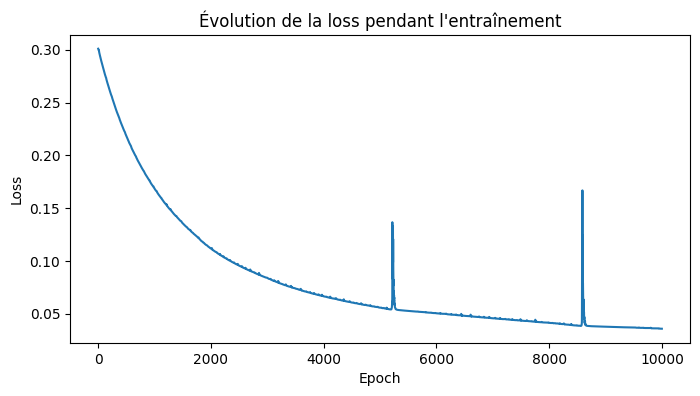

In [ ]:
plt.figure(figsize=(8, 4))

plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Évolution de la loss pendant l'entraînement")

plt.show()

## Évaluation du premier GCN

La diminution de la loss montre que le modèle apprend correctement sur les données d'entraînement. Cependant, cela ne permet pas encore de savoir s'il est capable de prédire le pays d'aéroports non utilisés pendant l'apprentissage.

Les performances sont donc mesurées séparément sur les ensembles d'entraînement, de validation et de test à l'aide de l'accuracy.

In [ ]:
@torch.no_grad()
def accuracy(mask):

    model.eval()

    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)

    correct = (pred[mask] == data.y[mask]).sum()
    acc = correct / mask.sum()

    return acc.item()

### Résultats sur les trois ensembles

L'accuracy est calculée sur les trois parties du jeu de données. La comparaison entre les résultats permet notamment de détecter un éventuel surapprentissage.

In [ ]:
train_acc = accuracy(data.train_mask)
val_acc = accuracy(data.val_mask)
test_acc = accuracy(data.test_mask)

print(f"Accuracy train      : {train_acc:.4f}")
print(f"Accuracy validation : {val_acc:.4f}")
print(f"Accuracy test       : {test_acc:.4f}")

Accuracy train      : 0.9900
Accuracy validation : 0.7516
Accuracy test       : 0.7611


### Premières prédictions

Quelques prédictions du modèle sont affichées avec les vraies classes afin d'observer plus concrètement les résultats obtenus.

## Analyse du premier modèle

Le premier GCN atteint une accuracy de 99 % sur les nœuds d'entraînement et d'environ 76 % sur les nœuds de test.

La différence entre ces résultats montre que le modèle s'adapte très fortement aux données d'entraînement. L'utilisation de 10 000 époques semble donc excessive.

Malgré cela, le résultat reste nettement supérieur à la baseline basée sur la classe majoritaire, qui obtient seulement 16,89 % sur le test.

La suite consiste à suivre les performances de validation pendant l'apprentissage afin de conserver le modèle au moment où sa capacité de généralisation est la meilleure.